In [1]:
# Task 04: Hand Gesture Recognition using SVM

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Automatically find the LeapGestRecog dataset

possible_paths = []

for root, dirs, files in os.walk("/kaggle/input"):
    if os.path.basename(root) == "leapGestRecog":
        possible_paths.append(root)

print("Dataset paths found:")

for path in possible_paths:
    print(path)

if len(possible_paths) == 0:
    raise FileNotFoundError("LeapGestRecog dataset was not found.")

DATASET_ROOT = possible_paths[0]

print("\nUsing dataset:")
print(DATASET_ROOT)

Dataset paths found:
/kaggle/input/datasets/gti-upm/leapgestrecog/leapGestRecog
/kaggle/input/datasets/gti-upm/leapgestrecog/leapgestrecog/leapGestRecog

Using dataset:
/kaggle/input/datasets/gti-upm/leapgestrecog/leapGestRecog


In [3]:
# Find subject folders

subjects = sorted([
    folder
    for folder in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, folder))
])

print("Number of subjects:", len(subjects))
print("Subjects:")

for subject in subjects:
    print(subject)

Number of subjects: 10
Subjects:
00
01
02
03
04
05
06
07
08
09


In [4]:
# Define the 10 hand gesture classes

class_names = [
    "01_palm",
    "02_l",
    "03_fist",
    "04_fist_moved",
    "05_thumb",
    "06_index",
    "07_ok",
    "08_palm_moved",
    "09_c",
    "10_down"
]

print("Number of gesture classes:", len(class_names))

for i, gesture in enumerate(class_names):
    print(i, "->", gesture)

Number of gesture classes: 10
0 -> 01_palm
1 -> 02_l
2 -> 03_fist
3 -> 04_fist_moved
4 -> 05_thumb
5 -> 06_index
6 -> 07_ok
7 -> 08_palm_moved
8 -> 09_c
9 -> 10_down


In [5]:
# Collect folders for each gesture across all subjects

gesture_folders = {}

for gesture in class_names:
    gesture_folders[gesture] = []

    for subject in subjects:
        gesture_path = os.path.join(
            DATASET_ROOT,
            subject,
            gesture
        )

        if os.path.isdir(gesture_path):
            gesture_folders[gesture].append(gesture_path)

print("Gesture folder summary:\n")

for gesture in class_names:
    print(
        gesture,
        "->",
        len(gesture_folders[gesture]),
        "subject folders"
    )

Gesture folder summary:

01_palm -> 10 subject folders
02_l -> 10 subject folders
03_fist -> 10 subject folders
04_fist_moved -> 10 subject folders
05_thumb -> 10 subject folders
06_index -> 10 subject folders
07_ok -> 10 subject folders
08_palm_moved -> 10 subject folders
09_c -> 10 subject folders
10_down -> 10 subject folders


In [7]:
# Count available images for each gesture

gesture_counts = {}

for gesture in class_names:

    count = 0

    for folder in gesture_folders[gesture]:

        files = [
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        count += len(files)

    gesture_counts[gesture] = count

print("Image count per gesture:\n")

for gesture in class_names:
    print(f"{gesture}: {gesture_counts[gesture]}")

Image count per gesture:

01_palm: 2000
02_l: 2000
03_fist: 2000
04_fist_moved: 2000
05_thumb: 2000
06_index: 2000
07_ok: 2000
08_palm_moved: 2000
09_c: 2000
10_down: 2000


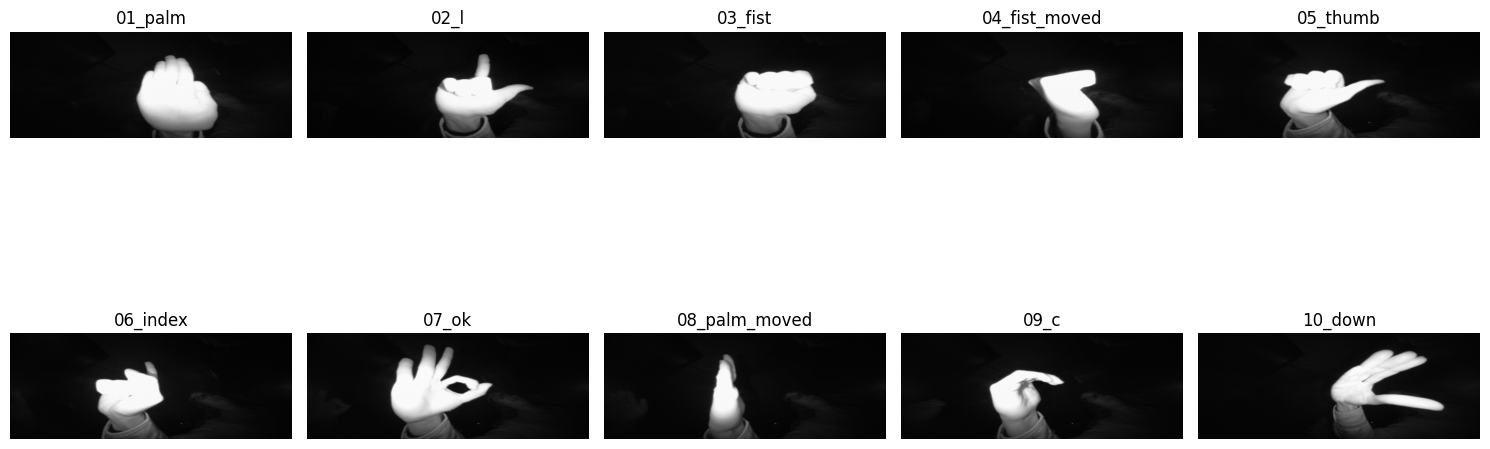

In [8]:
# Display one sample image from each gesture

plt.figure(figsize=(15, 8))

for i, gesture in enumerate(class_names):

    folder = gesture_folders[gesture][0]

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(folder, files[0])

    img = Image.open(image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(gesture)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Load images and extract HOG features

IMG_SIZE = (64, 64)
IMAGES_PER_CLASS = 200

X = []
y = []
image_paths = []

print("Starting image processing...\n")

for label, gesture in enumerate(class_names):

    all_images = []

    # Collect image paths
    for folder in gesture_folders[gesture]:

        files = [
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        for filename in files:
            all_images.append(
                os.path.join(folder, filename)
            )

    # Shuffle
    random.shuffle(all_images)

    # Select fixed number
    selected_images = all_images[:IMAGES_PER_CLASS]

    loaded = 0

    for image_path in selected_images:

        try:

            img = Image.open(image_path).convert("L")
            img = img.resize(IMG_SIZE)

            image_array = np.array(img, dtype=np.float32) / 255.0

            features = hog(
                image_array,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm="L2-Hys"
            )

            X.append(features)
            y.append(label)
            image_paths.append(image_path)

            loaded += 1

        except Exception:
            pass

    print(f"{gesture}: {loaded} images loaded")

X = np.array(X)
y = np.array(y)

print("\n==============================")
print("DATASET PREPARATION COMPLETE")
print("==============================")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Total images:", len(y))

Starting image processing...

01_palm: 200 images loaded
02_l: 200 images loaded
03_fist: 200 images loaded
04_fist_moved: 200 images loaded
05_thumb: 200 images loaded
06_index: 200 images loaded
07_ok: 200 images loaded
08_palm_moved: 200 images loaded
09_c: 200 images loaded
10_down: 200 images loaded

DATASET PREPARATION COMPLETE
X shape: (2000, 1764)
y shape: (2000,)
Total images: 2000


In [10]:
# Verify class distribution

class_distribution = pd.Series(y).value_counts().sort_index()

distribution_df = pd.DataFrame({
    "Gesture": class_names,
    "Images": [
        int(class_distribution.get(i, 0))
        for i in range(len(class_names))
    ]
})

print(distribution_df)

         Gesture  Images
0        01_palm     200
1           02_l     200
2        03_fist     200
3  04_fist_moved     200
4       05_thumb     200
5       06_index     200
6          07_ok     200
7  08_palm_moved     200
8           09_c     200
9        10_down     200


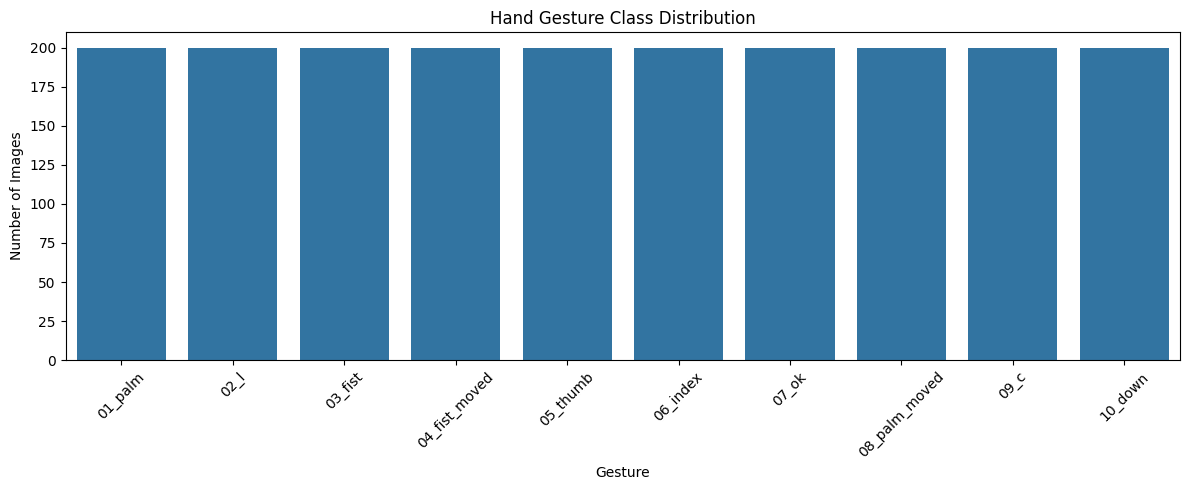

In [11]:
# Plot gesture distribution

plt.figure(figsize=(12, 5))

sns.barplot(
    data=distribution_df,
    x="Gesture",
    y="Images"
)

plt.title("Hand Gesture Class Distribution")
plt.xlabel("Gesture")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1600
Testing samples: 400


In [14]:
# Standardize HOG features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training feature shape:", X_train_scaled.shape)
print("Testing feature shape:", X_test_scaled.shape)

Feature scaling completed!
Training feature shape: (1600, 1764)
Testing feature shape: (400, 1764)


In [15]:
# Train Support Vector Machine classifier

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

print("Training SVM model...")

svm_model.fit(
    X_train_scaled,
    y_train
)

print("SVM model trained successfully!")

Training SVM model...
SVM model trained successfully!


In [16]:
# Make predictions on test data

y_pred = svm_model.predict(X_test_scaled)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 400


In [17]:
# Calculate model accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("====================================")
print("       SVM MODEL PERFORMANCE")
print("====================================")

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

       SVM MODEL PERFORMANCE
Test Accuracy: 0.9975
Accuracy Percentage: 99.75%


In [18]:
# Classification report

print("====================================")
print("       CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

       CLASSIFICATION REPORT
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00        40
         02_l       0.98      1.00      0.99        40
      03_fist       1.00      1.00      1.00        40
04_fist_moved       1.00      1.00      1.00        40
     05_thumb       1.00      1.00      1.00        40
     06_index       1.00      1.00      1.00        40
        07_ok       1.00      1.00      1.00        40
08_palm_moved       1.00      0.97      0.99        40
         09_c       1.00      1.00      1.00        40
      10_down       1.00      1.00      1.00        40

     accuracy                           1.00       400
    macro avg       1.00      1.00      1.00       400
 weighted avg       1.00      1.00      1.00       400



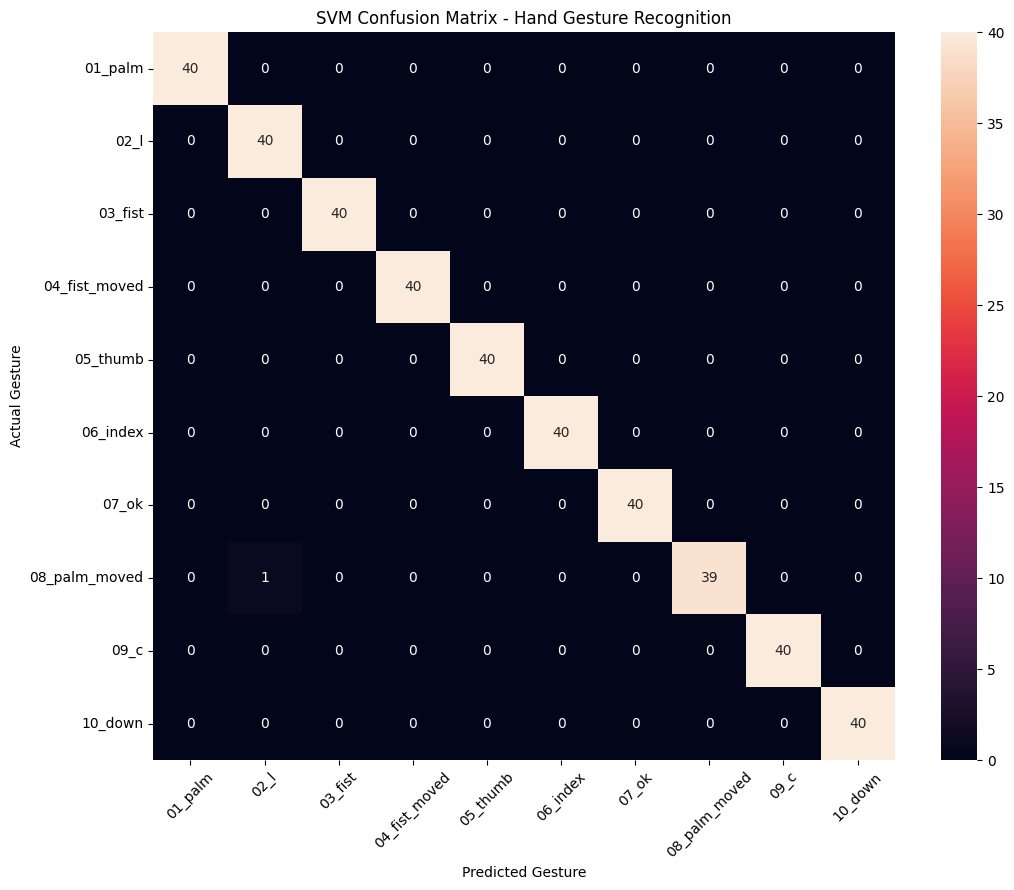

In [19]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("SVM Confusion Matrix - Hand Gesture Recognition")
plt.xlabel("Predicted Gesture")
plt.ylabel("Actual Gesture")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
# Function to predict a gesture from an image

def predict_gesture(image_path):

    img = Image.open(image_path).convert("L")
    img = img.resize(IMG_SIZE)

    image_array = np.array(
        img,
        dtype=np.float32
    ) / 255.0

    features = hog(
        image_array,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    features = scaler.transform([features])

    prediction = svm_model.predict(features)[0]

    return class_names[prediction]

print("Prediction function created successfully!")

Prediction function created successfully!


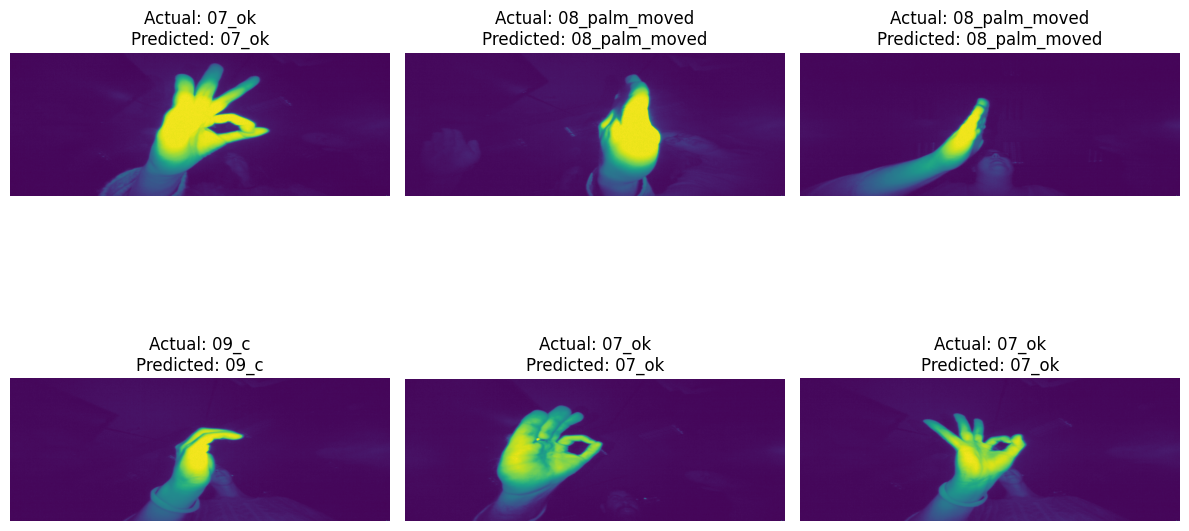

In [24]:
# Display actual images with predicted gestures

sample_indices = random.sample(
    range(len(image_paths)),
    6
)

plt.figure(figsize=(12, 8))

for i, index in enumerate(sample_indices):

    image_path = image_paths[index]

    actual = class_names[y[index]]

    predicted = predict_gesture(image_path)

    plt.subplot(2, 3, i + 1)

    plt.imshow(Image.open(image_path))

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
# Save trained SVM model, scaler and class names

joblib.dump(
    svm_model,
    "/kaggle/working/hand_gesture_svm_model.pkl"
)

joblib.dump(
    scaler,
    "/kaggle/working/hand_gesture_scaler.pkl"
)

joblib.dump(
    class_names,
    "/kaggle/working/gesture_class_names.pkl"
)

print("====================================")
print("FILES SAVED SUCCESSFULLY")
print("====================================")
print("✓ hand_gesture_svm_model.pkl")
print("✓ hand_gesture_scaler.pkl")
print("✓ gesture_class_names.pkl")

FILES SAVED SUCCESSFULLY
✓ hand_gesture_svm_model.pkl
✓ hand_gesture_scaler.pkl
✓ gesture_class_names.pkl


In [27]:
# Final Task 04 Summary

print("==============================================")
print("       TASK 04 COMPLETED SUCCESSFULLY")
print("==============================================")
print()

print("Task: Hand Gesture Recognition")
print("Dataset: Hand Gesture Recognition Database")
print("Algorithm: Support Vector Machine (SVM)")
print("Feature Extraction: HOG")
print("Number of Classes:", len(class_names))
print("Images Used:", len(y))
print(f"Test Accuracy: {accuracy * 100:.2f}%")

print()
print("Gesture Classes:")

for gesture in class_names:
    print("-", gesture)

print()
print("==============================================")

       TASK 04 COMPLETED SUCCESSFULLY

Task: Hand Gesture Recognition
Dataset: Hand Gesture Recognition Database
Algorithm: Support Vector Machine (SVM)
Feature Extraction: HOG
Number of Classes: 10
Images Used: 2000
Test Accuracy: 99.75%

Gesture Classes:
- 01_palm
- 02_l
- 03_fist
- 04_fist_moved
- 05_thumb
- 06_index
- 07_ok
- 08_palm_moved
- 09_c
- 10_down

